# Process GBD crosswalk model to get a split between antepartum and postpartum hemorrhage

GBD "crosswalks" data when they are from different definitions or measurements (colloqually, "dorms").
We typically do not interact with crosswalk models because they are preprocessing steps used on
input data and we are typically working with results.

However, in this case, the GBD cause available ("maternal hemorrhage") is not at the level of detail
that we wish to model (antepartum vs postpartum hemorrhage).
Luckily, they do have crosswalk models for adjusting input data that measure only one or the other
to be about both.
We can use the coefficients from these crosswalk models to estimate how much of the maternal hemorrhage incidence is due to antepartum vs postpartum hemorrhage.

There are two crosswalk models that we could use for this purpose, one that adjusts postpartum hemorrhage data to be like all hemorrhage data, and one that adjusts antepartum hemorrhage data to be like all hemorrhage data.
Presumably, postpartum hemorrhage and antepartum hemorrhage are MECE subsets of the total, but nothing actually enforces this in the GBD crosswalk models, and in practice we find that they are not exact complements of each other.
Instead, the crosswalk models say that postpartum hemorrhage is ~50% of hemorrhage, and antepartum hemorrhage is ~25% of hemorrhage, which leaves ~25% of hemorrhage unaccounted for.
We don't want to delete 25% of hemorrhage in our model, so we use only the postpartum hemorrhage crosswalk model, and assume the rest is antepartum.
This is a conservative assumption because we have interventions that act specifically on postpartum hemorrhage (we are assuming the unknown is all antepartum, which will minimize the impact of our interventions relative to other assumptions).

The data given to us by the GBD team (we corresponded with Jenny Faith and Mae Dirac) is in the form of a .pkl file, which is a Python pickle file.

When we load the pickle file, we receive an entire `CWModel` object from the crosswalk package, maintained by the MSCA team.
In order to interpret what this model is doing, we need to know about how it was created.
Here is the R function call (maps directly to the Python equivalent) that was used to create the model:

```R
fit1 <- cw$CWModel(
  cwdata = dat1,
  obs_type = "diff_log",
  cov_models = list(
    cw$CovModel("intercept"),
    cw$CovModel(cov_name = "age",
                spline = cw$XSpline(degree = 2L, knots = c(20, 30, 40, 50),
                                    l_linear = TRUE,
                                    r_linear = TRUE))),
  gold_dorm = "all_hem")
```

The gold standard dorm is "all_hem", which means that the model is trying to adjust data from other dorms to be like "all_hem".
The model can take input data from dorm "postpartum_hem".
It models differences in logarithmic space, so a pred_diff_sd output of 0 would mean that the two dorms are the same, and therefore postpartum hemorrhage is the same as all hemorrhage, and therefore there is no antepartum hemorrhage.
We corresponded with Ariane Ducellier about the formulas needed.

Note that crosswalk models can make predictions both including and excluding between-study variability (this parameter is called gamma).
This is the difference between the lighter and darker shaded areas in the following plot displaying this crosswalk model (left pane):

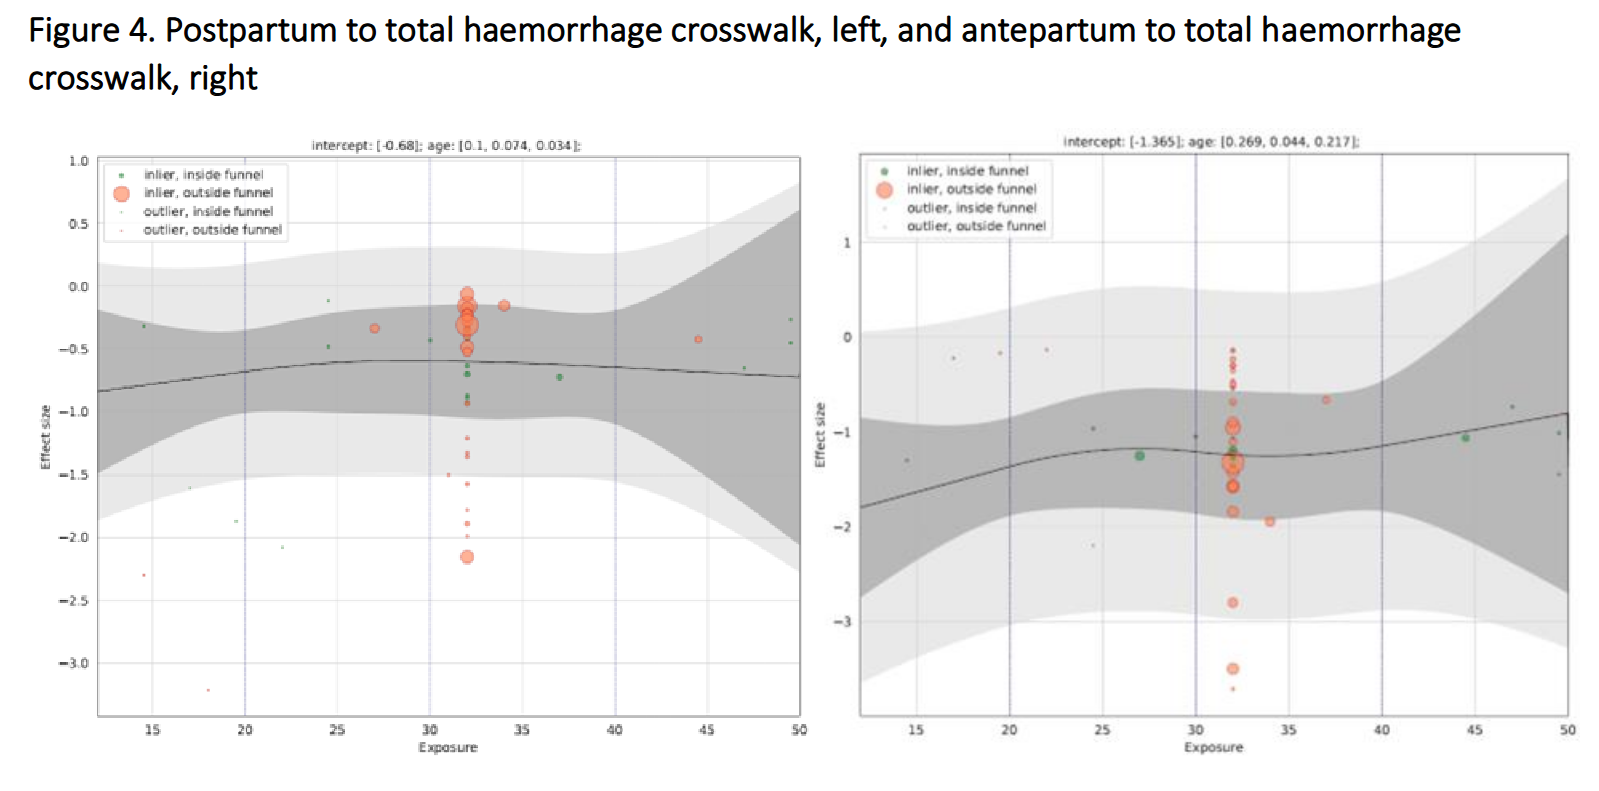

We want to make predictions **without** including the between-study variability.
In GBD when generating *results* from meta-analysis, typically the between-study variability is not propagated (though I believe there are some exceptions to this in BoP analyses).
Crosswalk models, when used for preprocessing data, typically make predictions *including* between-study variability, but this is not appropriate for our purpose of
crosswalking "true" (estimated) values rather than the values from individual studies.

In [1]:
import crosswalk
import pandas as pd, numpy as np

In [2]:
import pickle

# Open the file in read-binary mode
with open('results.pkl', 'rb') as file:
    # Load the object from the file
    model = pickle.load(file)

In [3]:
model

In [4]:
input_df = pd.DataFrame({
    'dorm': 'postpartum_hem',
    'to_dorm': 'all_hem',
    'age': [12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5], # midpoints of age groups
    'mean': 1.0,
    'se': 0.0,
})
crosswalked = input_df.join(model.adjust_orig_vals(
    input_df,
    orig_dorms='dorm',
    orig_vals_mean='mean',
    orig_vals_se='se',
    ref_dorms='to_dorm',
))
crosswalked

,dorm,to_dorm,age,mean,se,ref_vals_mean,ref_vals_sd,pred_diff_mean,pred_diff_sd,data_id
0,postpartum_hem,all_hem,12.5,1.0,0.0,2.291181,1.171599,-0.829067,0.314744,0
1,postpartum_hem,all_hem,17.5,1.0,0.0,2.074018,0.922683,-0.729488,0.188411,1
2,postpartum_hem,all_hem,22.5,1.0,0.0,1.890693,0.835478,-0.636943,0.181245,2
3,postpartum_hem,all_hem,27.5,1.0,0.0,1.810568,0.825395,-0.593641,0.213088,3
4,postpartum_hem,all_hem,32.5,1.0,0.0,1.824436,0.846472,-0.601271,0.229882,4
5,postpartum_hem,all_hem,37.5,1.0,0.0,1.873420,0.851469,-0.627765,0.210128,5
6,postpartum_hem,all_hem,42.5,1.0,0.0,1.946612,0.990966,-0.666090,0.311027,6
7,postpartum_hem,all_hem,47.5,1.0,0.0,2.026085,1.380230,-0.706105,0.549234,7
8,postpartum_hem,all_hem,52.5,1.0,0.0,1.973282,0.860065,-0.679698,0.165991,8


In [5]:
# Checking the formulas
# https://github.com/ihmeuw-msca/crosswalk/blob/419ae495850dc57a7426b89e76e703d53c60a6cb/src/crosswalk/utils.py#L167-L168
assert np.allclose(np.exp(crosswalked['pred_diff_mean']), 1 / crosswalked['ref_vals_mean'])
log_space_full_sd = crosswalked['ref_vals_sd'] / crosswalked['ref_vals_mean']
# The difference between the full SD and the pred_diff_sd is the inclusion of between study variability (gamma)
assert np.allclose(np.sqrt(log_space_full_sd**2 - model.gamma), crosswalked['pred_diff_sd'])

In [ ]:
crosswalked['age_start'] = crosswalked['age'] - 2.5
crosswalked['age_end'] = crosswalked['age'] + 2.5
crosswalked['sex'] = 'Female'
crosswalked = crosswalked.set_index(['age_start', 'age_end', 'sex'])[['pred_diff_mean', 'pred_diff_sd']]
crosswalked

,,,pred_diff_mean,pred_diff_sd
age_start,age_end,sex,,
10.0,15.0,Female,-0.829067,0.314744
15.0,20.0,Female,-0.729488,0.188411
20.0,25.0,Female,-0.636943,0.181245
25.0,30.0,Female,-0.593641,0.213088
30.0,35.0,Female,-0.601271,0.229882
35.0,40.0,Female,-0.627765,0.210128
40.0,45.0,Female,-0.666090,0.311027
45.0,50.0,Female,-0.706105,0.549234
50.0,55.0,Female,-0.679698,0.165991


These means and standard deviations are of the predictions of log differences.

The fact that the means are all negative makes sense, because postpartum hemorrhage is a subset of all hemorrhage, so we expect it to be less common.

We will sample draw values, and exponentiate to get multiplicative differences,
in artifact creation.

In [7]:
crosswalked.round(6).to_csv('crosswalk_parameters.csv')
print(f"Saved crosswalk parameters")

Saved crosswalk parameters
